In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [38]:
df = pd.read_csv('retail_price.csv')

In [39]:
df

,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed1,bed_bath_table,01-05-2017,1,45.95,15.100000,45.950000,39,161,2,...,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.900000
1,bed1,bed_bath_table,01-06-2017,3,137.85,12.933333,45.950000,39,161,2,...,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.950000
2,bed1,bed_bath_table,01-07-2017,6,275.70,14.840000,45.950000,39,161,2,...,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.950000
3,bed1,bed_bath_table,01-08-2017,4,183.80,14.287500,45.950000,39,161,2,...,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.950000
4,bed1,bed_bath_table,01-09-2017,2,91.90,15.100000,45.950000,39,161,2,...,89.9,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.950000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
671,bed5,bed_bath_table,01-05-2017,1,215.00,8.760000,215.000000,56,162,5,...,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,214.950000
672,bed5,bed_bath_table,01-06-2017,10,2090.00,21.322000,209.000000,56,162,5,...,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,215.000000
673,bed5,bed_bath_table,01-07-2017,59,12095.00,22.195932,205.000000,56,162,5,...,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,209.000000
674,bed5,bed_bath_table,01-08-2017,52,10375.00,19.412885,199.509804,56,162,5,...,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,205.000000


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 676 entries, 0 to 675
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  676 non-null    object 
 1   product_category_name       676 non-null    object 
 2   month_year                  676 non-null    object 
 3   qty                         676 non-null    int64  
 4   total_price                 676 non-null    float64
 5   freight_price               676 non-null    float64
 6   unit_price                  676 non-null    float64
 7   product_name_lenght         676 non-null    int64  
 8   product_description_lenght  676 non-null    int64  
 9   product_photos_qty          676 non-null    int64  
 10  product_weight_g            676 non-null    int64  
 11  product_score               676 non-null    float64
 12  customers                   676 non-null    int64  
 13  weekday                     676 non

In [41]:
df['month_year'] = pd.to_datetime(df['month_year'], format = 'mixed',dayfirst= True)
df['month'] = df['month_year'].dt.month
df['year'] = df['month_year'].dt.year

In [42]:
df['average_price'] = df[['comp_1','comp_2','comp_3']].mean(axis =1)

In [43]:
df['price_gap']= df['unit_price'] - df['average_price']

In [44]:
df['price_ratio'] = df['unit_price']/df['average_price']

<Axes: xlabel='qty', ylabel='unit_price'>

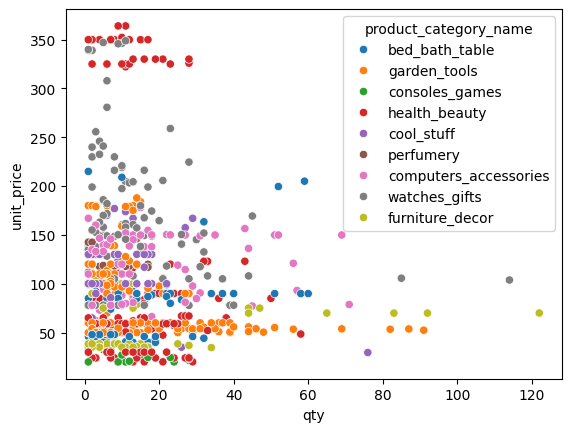

In [45]:
sns.scatterplot(x='qty',y = 'unit_price',data = df,hue='product_category_name')

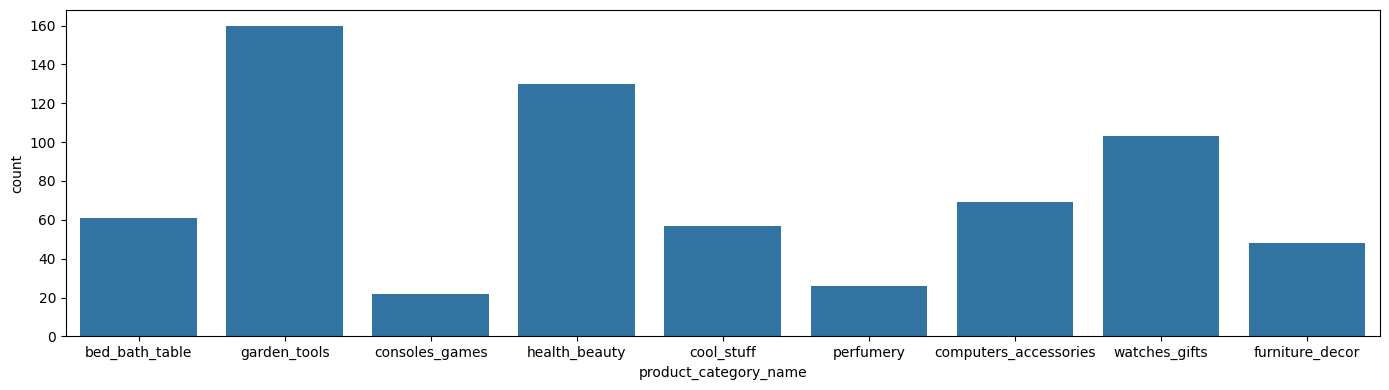

In [46]:
plt.figure(figsize=(14,4))
sns.countplot(data = df,x='product_category_name')
plt.tight_layout()

In [47]:
df.columns

Index(['product_id', 'product_category_name', 'month_year', 'qty',
       'total_price', 'freight_price', 'unit_price', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_score', 'customers', 'weekday', 'weekend', 'holiday', 'month',
       'year', 's', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2',
       'comp_3', 'ps3', 'fp3', 'lag_price', 'average_price', 'price_gap',
       'price_ratio'],
      dtype='object')

In [48]:
df['average_score'] = df[['ps1','ps2','ps3']].mean(axis =1)
df['score_gap']= df['product_score']-df['average_score']

In [49]:
df['average_freight'] = df[['fp1','fp2','fp3']].mean(axis = 1)

In [50]:
df['freight_gap']= df['freight_price']- df['average_freight']

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 676 entries, 0 to 675
Data columns (total 37 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   product_id                  676 non-null    object        
 1   product_category_name       676 non-null    object        
 2   month_year                  676 non-null    datetime64[ns]
 3   qty                         676 non-null    int64         
 4   total_price                 676 non-null    float64       
 5   freight_price               676 non-null    float64       
 6   unit_price                  676 non-null    float64       
 7   product_name_lenght         676 non-null    int64         
 8   product_description_lenght  676 non-null    int64         
 9   product_photos_qty          676 non-null    int64         
 10  product_weight_g            676 non-null    int64         
 11  product_score               676 non-null    float64       

In [52]:
import sqlite3
import pandas as pd

# Assume df_historical and df_forecast are already loaded in your environment
# df_historical = pd.read_csv('...') 
# df_forecast = pd.read_csv('...')

# 1. Create a connection to a new SQLite database file
conn = sqlite3.connect('smart_markdown.db')

# 2. Push the DataFrames to SQLite
# We use index=False so pandas doesn't write the row indices as a column

df.to_sql('retailer_data', conn, if_exists='replace', index=False)

# 3. Close the connection
conn.close()
print("Database 'smart_markdown.db' created successfully!")

Database 'smart_markdown.db' created successfully!


In [17]:
df['product_id'].nunique()

52

In [18]:
import category_encoders as ce

# 1. Initialize the Binary Encoder
# We apply it to 'product_id' and 'product_category_name'
be = ce.BinaryEncoder(cols=['product_id','product_category_name'])

# 2. Transform the data
# This creates columns like product_id_0, product_id_1... product_id_5
df_encoded = be.fit_transform(df)

# 3. View the new features
new_cols = [c for c in df_encoded.columns if 'product_id_' in c]
print(f"Created {len(new_cols)} columns for 52 products:")
print(df_encoded[new_cols].head())

Created 6 columns for 52 products:
   product_id_0  product_id_1  product_id_2  product_id_3  product_id_4  \
0             0             0             0             0             0   
1             0             0             0             0             0   
2             0             0             0             0             0   
3             0             0             0             0             0   
4             0             0             0             0             0   

   product_id_5  
0             1  
1             1  
2             1  
3             1  
4             1  


In [19]:
df_encoded

,product_id_0,product_id_1,product_id_2,product_id_3,product_id_4,product_id_5,product_category_name_0,product_category_name_1,product_category_name_2,product_category_name_3,...,ps3,fp3,lag_price,average_price,price_gap,price_ratio,average_score,score_gap,average_freight,freight_gap
0,0,0,0,0,0,1,0,0,0,1,...,4.0,15.100000,45.900000,116.950000,-71.000000,0.392903,4.1,-0.1,12.957299,2.142701
1,0,0,0,0,0,1,0,0,0,1,...,4.0,12.933333,45.950000,114.950000,-69.000000,0.399739,4.1,-0.1,16.341516,-3.408183
2,0,0,0,0,0,1,0,0,0,1,...,4.0,14.840000,45.950000,113.616667,-67.666667,0.404430,4.1,-0.1,17.009922,-2.169922
3,0,0,0,0,0,1,0,0,0,1,...,4.0,14.287500,45.950000,111.786601,-65.836601,0.411051,4.1,-0.1,16.119047,-1.831547
4,0,0,0,0,0,1,0,0,0,1,...,4.0,15.100000,45.950000,99.749570,-53.799570,0.460654,4.1,-0.1,19.400403,-4.300403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
671,1,1,0,1,0,0,0,0,0,1,...,4.0,15.100000,214.950000,116.950000,98.050000,1.838392,4.1,0.3,12.957299,-4.197299
672,1,1,0,1,0,0,0,0,0,1,...,4.0,12.933333,215.000000,114.950000,94.050000,1.818182,4.1,0.3,16.341516,4.980484
673,1,1,0,1,0,0,0,0,0,1,...,4.0,14.840000,209.000000,113.616667,91.383333,1.804313,4.1,0.3,17.009922,5.186010
674,1,1,0,1,0,0,0,0,0,1,...,4.0,14.287500,205.000000,111.786601,87.723203,1.784738,4.1,0.3,16.119047,3.293837


In [20]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 676 entries, 0 to 675
Data columns (total 45 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   product_id_0                676 non-null    int64         
 1   product_id_1                676 non-null    int64         
 2   product_id_2                676 non-null    int64         
 3   product_id_3                676 non-null    int64         
 4   product_id_4                676 non-null    int64         
 5   product_id_5                676 non-null    int64         
 6   product_category_name_0     676 non-null    int64         
 7   product_category_name_1     676 non-null    int64         
 8   product_category_name_2     676 non-null    int64         
 9   product_category_name_3     676 non-null    int64         
 10  month_year                  676 non-null    datetime64[ns]
 11  qty                         676 non-null    int64         

In [21]:
#Define features (including the new binary columns)
binary_cols = [c for c in df_encoded.columns if 'product_id_' in c or 'product_category_' in c]
static_nums = ['product_weight_g', 'volume', 'product_score', 'product_photos_qty','average_freight']
features = binary_cols + static_nums

X = df_encoded[features]
y = df_encoded['unit_price']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
from xgboost import XGBRegressor
base_model = XGBRegressor(n_estimators=150, learning_rate=0.05, max_depth=5)
base_model.fit(X, y)

# Save the predictions as your "Base Price"
pred = base_model.predict(X_test)

In [23]:
from sklearn.metrics import mean_squared_error

In [24]:
print(mean_squared_error(y_test, pred))

81.32032127192848


In [25]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test,pred)
print(f"Base Model Error: {mape:.2%}")

Base Model Error: 7.70%


In [26]:
df['predicted_base_price']= base_model.predict(X)

In [27]:
floor_prices = df.groupby('product_id')['unit_price'].min().reset_index()
floor_prices.columns = ['product_id', 'historical_min_price']

df = df.merge(floor_prices, on='product_id', how='left')

df['safety_floor'] = df['historical_min_price'] * 0.90

df['max_markdown_allowance'] = df['predicted_base_price'] - df['safety_floor']

# Check how many products have a Base Price comfortably above the floor
print(df[['product_id', 'predicted_base_price', 'safety_floor', 'max_markdown_allowance']])

    product_id  predicted_base_price  safety_floor  max_markdown_allowance
0         bed1             45.711288     35.316000               10.395288
1         bed1             45.864483     35.316000               10.548483
2         bed1             45.864483     35.316000               10.548483
3         bed1             45.864483     35.316000               10.548483
4         bed1             44.007355     35.316000                8.691355
..         ...                   ...           ...                     ...
671       bed5            199.600433    147.058839               52.541595
672       bed5            196.719894    147.058839               49.661056
673       bed5            196.719894    147.058839               49.661056
674       bed5            196.719894    147.058839               49.661056
675       bed5            179.071045    147.058839               32.012206

[676 rows x 4 columns]


In [28]:
df.columns

Index(['product_id', 'product_category_name', 'month_year', 'qty',
       'total_price', 'freight_price', 'unit_price', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_score', 'customers', 'weekday', 'weekend', 'holiday', 'month',
       'year', 's', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2',
       'comp_3', 'ps3', 'fp3', 'lag_price', 'average_price', 'price_gap',
       'price_ratio', 'average_score', 'score_gap', 'average_freight',
       'freight_gap', 'predicted_base_price', 'historical_min_price',
       'safety_floor', 'max_markdown_allowance'],
      dtype='object')

In [29]:
import pmdarima as pm
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

def forecast_robust(df, periods=3):
    df['month_year'] = pd.to_datetime(df['month_year'])
    df = df.sort_values(['product_id', 'month_year'])
    
    forecast_results = []
    
    unique_products = df['product_id'].unique()
    print(f"Processing {len(unique_products)} products...")
    
    for pid in unique_products:
        # 1. Isolation & Cleaning
        subset = df[df['product_id'] == pid].copy()
        subset.set_index('month_year', inplace=True)
        
        # FILL NA: Critical fix for "Input contains NaN" error
        subset = subset.fillna(0)
        
        y = subset['qty']
        # Ensure Exog features exist and are clean
        if 'holiday' in subset.columns and 'price_ratio' in subset.columns:
            X = subset[['holiday', 'price_ratio']].fillna(0)
        else:
            X = None
            
        n_samples = len(y)
        
        # 2. Adaptive Logic based on Data Length
        try:
            model = None
            
            # SCENARIO A: Rich History (> 20 months) -> Full Seasonal ARIMA
            if n_samples >= 20:
                model = pm.auto_arima(y, X=X,
                                      seasonal=True, m=12, 
                                      d=None, D=1, # Allow seasonal differencing
                                      start_p=0, max_p=3,
                                      start_q=0, max_q=3,
                                      error_action='ignore',
                                      suppress_warnings=True)
                
            # SCENARIO B: Medium History (6-19 months) -> Non-Seasonal ARIMA
            elif n_samples >= 6:
                # We turn OFF seasonality (m=1) to prevent the "D=1 too large" error
                model = pm.auto_arima(y, X=X,
                                      seasonal=False, m=1, 
                                      d=None, 
                                      error_action='ignore',
                                      suppress_warnings=True)
                
            # SCENARIO C: Sparse Data (< 6 months) -> Simple Moving Average
            else:
                raise ValueError("Not enough data for ARIMA")

            # 3. Create Future Scenario (same as before)
            future_dates = [subset.index[-1] + pd.DateOffset(months=x+1) for x in range(periods)]
            
            if X is not None:
                future_X = pd.DataFrame(index=future_dates)
                future_X['holiday'] = 0 # Default no holiday
                future_X['price_ratio'] = X['price_ratio'].iloc[-1] # Default same price
            else:
                future_X = None

            # 4. Predict
            forecast, conf_int = model.predict(n_periods=periods, X=future_X, return_conf_int=True)
            
            for date, val, (lower, upper) in zip(future_dates, forecast, conf_int):
                forecast_results.append({
                    'product_id': pid,
                    'forecast_date': date,
                    'forecasted_qty': round(max(0, val), 2),
                    'model_type': 'Seasonal' if n_samples >= 20 else 'Non-Seasonal'
                })

        except Exception as e:
            # Fallback for ANY failure (NaNs, convergence issues, tiny data)
            # Use Simple Average of last 3 months
            fallback_val = y.tail(3).mean()
            if pd.isna(fallback_val): fallback_val = 0
            
            for i in range(periods):
                date = subset.index[-1] + pd.DateOffset(months=i+1)
                forecast_results.append({
                    'product_id': pid,
                    'forecast_date': date,
                    'forecasted_qty': round(fallback_val, 2),
                    'model_type': 'Fallback (Mean)'
                })
            # print(f"Fallback used for {pid} due to: {str(e)[:50]}...")

    return pd.DataFrame(forecast_results)

# Run the robust script
final_forecast = forecast_robust(df)
print(final_forecast.head(10))

Processing 52 products...
  product_id forecast_date  forecasted_qty    model_type
0       bed1    2018-09-01            8.05  Non-Seasonal
1       bed1    2018-10-01            8.75  Non-Seasonal
2       bed1    2018-11-01            9.64  Non-Seasonal
3       bed2    2018-09-01            8.35  Non-Seasonal
4       bed2    2018-10-01            9.97  Non-Seasonal
5       bed2    2018-11-01            9.97  Non-Seasonal
6       bed3    2018-09-01            4.71  Non-Seasonal
7       bed3    2018-10-01            4.71  Non-Seasonal
8       bed3    2018-11-01            4.71  Non-Seasonal
9       bed4    2018-08-01            0.00  Non-Seasonal


In [30]:

def generate_smart_markdowns(df, forecast_df):
    """
    Scales the predicted_base_price based on the demand forecast.
    """
    # 1. Calculate Historical Average Demand for each product
    # This acts as our "Baseline" to compare against the forecast
    avg_demand = df.groupby('product_id')['qty'].mean().reset_index()
    avg_demand.columns = ['product_id', 'avg_historical_qty']

    # 2. Get the latest Base Price & Safety Floor for each product
    # We take the most recent known values from your main dataframe
    latest_info = df.sort_values('month_year').groupby('product_id').tail(1)
    base_price_map = latest_info[['product_id', 'predicted_base_price', 'safety_floor']]

    # 3. Merge Forecasts with Base Prices and Historical Averages
    markdown_engine = forecast_df.merge(base_price_map, on='product_id', how='left')
    markdown_engine = markdown_engine.merge(avg_demand, on='product_id', how='left')

    # Fill any NaNs (e.g., new products with no history) to avoid errors
    markdown_engine['avg_historical_qty'] = markdown_engine['avg_historical_qty'].fillna(0)
    markdown_engine['predicted_base_price'] = markdown_engine['predicted_base_price'].fillna(0)
    markdown_engine['safety_floor'] = markdown_engine['safety_floor'].fillna(0)

    # 4. Calculate Demand Ratio
    # Logic: Predicted / Historical
    # If ratio > 1.0, demand is booming. If < 1.0, demand is slowing.
    # We use a small epsilon (1e-6) to avoid division by zero
    markdown_engine['demand_ratio'] = markdown_engine['forecasted_qty'] / (markdown_engine['avg_historical_qty'] + 1e-6)

    # 5. Define the Scaling Factor (The Markdown Logic)
    # If demand is low, we discount. We use sqrt to dampen the effect so prices don't crash.
    # Example: If demand is 50% of normal (0.5), sqrt(0.5) is ~0.71.
    # So we set price to 71% of Base (29% off).
    markdown_engine['scaling_factor'] = np.where(
        markdown_engine['demand_ratio'] < 1.0,
        np.sqrt(markdown_engine['demand_ratio']), # Apply markdown
        1.0 # Keep full price
    )

    # Cap the scaling factor at 0.5 (Maximum 50% off) just to be safe
    markdown_engine['scaling_factor'] = markdown_engine['scaling_factor'].clip(lower=0.5)

    # 6. Calculate Final Recommended Price
    markdown_engine['recommended_price'] = markdown_engine['predicted_base_price'] * markdown_engine['scaling_factor']

    # 7. Apply Safety Floor (Critical Step)
    # Never suggest a price lower than the historical minimum (safety_floor)
    markdown_engine['final_smart_price'] = markdown_engine[['recommended_price', 'safety_floor']].max(axis=1)

    # 8. Calculate Discount Percentage for Reporting
    # (Base - Final) / Base
    markdown_engine['markdown_pct'] = (1 - (markdown_engine['final_smart_price'] / (markdown_engine['predicted_base_price'] + 1e-6))) * 100
    markdown_engine['markdown_pct'] = markdown_engine['markdown_pct'].clip(lower=0) # No negative markdowns

    return markdown_engine

# --- Usage ---
# Assuming 'df' is your main data and 'final_forecast' is the output from the previous step
smart_prices = generate_smart_markdowns(df, final_forecast)

# Display the recommendations for the next month
cols_to_show = ['product_id', 'forecast_date', 'forecasted_qty', 'avg_historical_qty',
                'predicted_base_price', 'final_smart_price', 'markdown_pct']

print(smart_prices[cols_to_show].tail(10))

    product_id forecast_date  forecasted_qty  avg_historical_qty  \
146   watches5    2018-08-01           19.77           14.300000   
147   watches6    2018-09-01            0.00           23.071429   
148   watches6    2018-10-01            2.48           23.071429   
149   watches6    2018-11-01            2.48           23.071429   
150   watches7    2018-08-01           16.38           10.250000   
151   watches7    2018-09-01           44.36           10.250000   
152   watches7    2018-10-01           24.71           10.250000   
153   watches8    2018-09-01            1.65           11.700000   
154   watches8    2018-10-01            0.69           11.700000   
155   watches8    2018-11-01            1.36           11.700000   

     predicted_base_price  final_smart_price  markdown_pct  
146            199.376404         199.376404      0.000000  
147            128.877426          93.413271     27.517740  
148            128.877426          93.413271     27.517740  
149    

In [31]:
print(smart_prices[smart_prices['product_id']=='watches6'][cols_to_show])

    product_id forecast_date  forecasted_qty  avg_historical_qty  \
147   watches6    2018-09-01            0.00           23.071429   
148   watches6    2018-10-01            2.48           23.071429   
149   watches6    2018-11-01            2.48           23.071429   

     predicted_base_price  final_smart_price  markdown_pct  
147            128.877426          93.413271      27.51774  
148            128.877426          93.413271      27.51774  
149            128.877426          93.413271      27.51774  


In [32]:
smart_prices.to_csv('smart_price_recommendations.csv', index=False)

In [35]:
smart_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   product_id            156 non-null    object        
 1   forecast_date         156 non-null    datetime64[ns]
 2   forecasted_qty        156 non-null    float64       
 3   model_type            156 non-null    object        
 4   predicted_base_price  156 non-null    float32       
 5   safety_floor          156 non-null    float64       
 6   avg_historical_qty    156 non-null    float64       
 7   demand_ratio          156 non-null    float64       
 8   scaling_factor        156 non-null    float64       
 9   recommended_price     156 non-null    float64       
 10  final_smart_price     156 non-null    float64       
 11  markdown_pct          156 non-null    float64       
dtypes: datetime64[ns](1), float32(1), float64(8), object(2)
memory usage: 14.1+ KB

In [54]:
import sqlite3

# 1. Create/connect to the database file in your devops folder
conn = sqlite3.connect('smart_markdown.db')

# 2. Push your existing DataFrames into SQLite tables
# Replace 'df' and 'df_forecast' if your variables are named differently
df.to_sql('historical_data', conn, if_exists='replace', index=False)
smart_prices.to_sql('forecast_data', conn, if_exists='replace', index=False)

# 3. Close the connection
conn.close()
print("Data successfully loaded into smart_markdown.db!")

Data successfully loaded into smart_markdown.db!
